<a href="https://colab.research.google.com/github/EksaMuhammad/UTS-SBP-Kel-5/blob/main/Kelompok5_SBP_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mengolah Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Semua library berhasil diimport.")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")


Semua library berhasil diimport.
   pandas 2.2.2 | numpy 2.0.2


## Load Data

In [ ]:
# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv('student_mental_health_burnout.csv')

print(f"Jumlah data : {len(df):,} baris × {df.shape[1]} kolom")
print(f"Kolom       : {list(df.columns)}")
print()
df.head(5)

Jumlah data : 150,000 baris × 20 kolom
Kolom       : ['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']



,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [ ]:
# ── Informasi tipe data & missing values ──────────────────────
print("=== Tipe Data ===")
print(df.dtypes.to_string())
print()
print("=== Missing Values ===")
mv = df.isnull().sum()
print(mv[mv > 0] if mv.any() else "Tidak ada missing values")


=== Tipe Data ===
student_id                   int64
age                          int64
gender                      object
course                      object
year                        object
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                object
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality               object
attendance_percentage      float64
cgpa                       float64
internet_quality            object
burnout_level               object

=== Missing Values ===
Tidak ada missing values


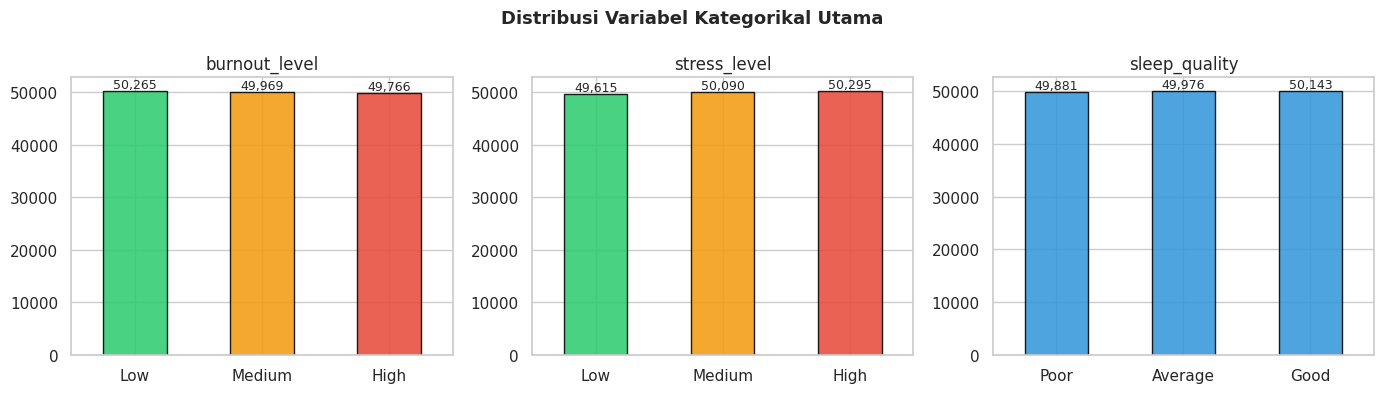

Distribusi kelas sangat seimbang — ideal untuk sistem pakar.


In [ ]:
# ── Distribusi variabel target & kategorikal utama ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi Variabel Kategorikal Utama', fontsize=13, fontweight='bold')

palette = {'Low':'#2ecc71', 'Medium':'#f39c12', 'High':'#e74c3c'}

for ax, col in zip(axes, ['burnout_level', 'stress_level', 'sleep_quality']):
    order = ['Low','Medium','High'] if col != 'sleep_quality' else ['Poor','Average','Good']
    counts = df[col].value_counts().reindex(order)
    colors = [palette.get(k, '#3498db') for k in order]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.88)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_kategorikal.png', dpi=120, bbox_inches='tight')
plt.show()
print("Distribusi kelas sangat seimbang — ideal untuk sistem pakar.")


# Preprocessing Data

In [ ]:
# Hapus duplikat
df = df.drop_duplicates()

# Missing value
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Bersihkan string
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Outlier handling
df['daily_study_hours'] = df['daily_study_hours'].clip(0, 16)
df['screen_time_hours'] = df['screen_time_hours'].clip(0, 20)
df['anxiety_score'] = df['anxiety_score'].clip(0, 10)
df['depression_score'] = df['depression_score'].clip(0, 10)
df['academic_pressure_score'] = df['academic_pressure_score'].clip(0, 10)

# Pilih Variabel Burnout + TI

In [ ]:
# ===============================
# SELECTED VARIABLES (ASLI DATASET)
# ===============================
SELECTED_VARS = [
    'stress_level',
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'sleep_quality',
    'daily_study_hours',
    'screen_time_hours',
    'internet_quality',
    'burnout_level'
]

df_selected = df[SELECTED_VARS].copy()


# ===============================
# NORMALISASI
# ===============================
df_selected['stress_level'] = df_selected['stress_level'].str.lower()
df_selected['sleep_quality'] = df_selected['sleep_quality'].str.lower()
df_selected['internet_quality'] = df_selected['internet_quality'].str.lower()
df_selected['burnout_level'] = df_selected['burnout_level'].str.lower()


# ============================================================
# TAMBAHAN VARIABEL KHUSUS MAHASISWA TI (GENERATED)
# ============================================================

# Coding hours (proxy dari study + screen time)
df_selected['coding_hours'] = (
    df_selected['daily_study_hours'] * 0.6 +
    df_selected['screen_time_hours'] * 0.4
)

# Debugging stress (dari anxiety + academic pressure)
df_selected['debugging_stress'] = (
    df_selected['anxiety_score'] + df_selected['academic_pressure_score']
) / 2

# Deadline pressure
df_selected['tugas_deadline'] = df_selected['academic_pressure_score'].apply(
    lambda x: 'high' if x >= 7 else 'low'
)

# Project load
df_selected['project_load'] = df_selected['daily_study_hours'].apply(
    lambda x: 'high' if x > 7 else 'low'
)

# Praktikum pressure
df_selected['praktikum_pressure'] = df_selected['academic_pressure_score'].apply(
    lambda x: 'high' if x >= 7 else 'low'
)

# Screen time kategori
df_selected['screen_time'] = df_selected['screen_time_hours'].apply(
    lambda x: 'high' if x > 8 else 'low'
)


print("Dataset setelah tambahan variabel TI:")
display(df_selected.head())

Dataset setelah tambahan variabel TI:


,stress_level,anxiety_score,depression_score,academic_pressure_score,sleep_quality,daily_study_hours,screen_time_hours,internet_quality,burnout_level,coding_hours,debugging_stress,tugas_deadline,project_load,praktikum_pressure,screen_time
0,high,10,3,4,average,4.3,6.1,good,high,5.02,7.0,low,low,low,low
1,high,2,10,8,poor,1.4,3.0,poor,low,2.04,5.0,high,low,high,low
2,low,2,7,8,good,3.7,1.5,good,high,2.82,5.0,high,low,high,low
3,high,3,3,4,poor,1.6,7.0,good,high,3.76,3.5,low,low,low,low
4,high,7,7,6,good,2.0,5.4,good,low,3.36,6.5,low,low,low,low


#Tranformasi Fakta

In [ ]:
def transform_to_facts(row):
    facts = set()

    # ===== FIX: pakai angka, bukan kolom yang tidak ada =====
    if row['stress_level'] in ['high']:
        facts.add('stress_tinggi')

    if row['anxiety_score'] >= 7:
        facts.add('cemas')

    if row['depression_score'] >= 7:
        facts.add('depresi')

    if row['sleep_quality'] in ['poor']:
        facts.add('tidur_buruk')

    if row['academic_pressure_score'] >= 7:
        facts.add('tekanan_akademik')

    if row['daily_study_hours'] > 8:
        facts.add('belajar_berlebihan')

    # ===== TI =====
    if row['screen_time'] == 'high':
        facts.add('screen_time_tinggi')

    if row['coding_hours'] > 6:
        facts.add('coding_berlebihan')

    if row['debugging_stress'] >= 7:
        facts.add('stress_debugging')

    if row['tugas_deadline'] == 'high':
        facts.add('deadline_tinggi')

    if row['project_load'] == 'high':
        facts.add('banyak_project')

    if row['internet_quality'] == 'poor':
        facts.add('internet_buruk')

    if row['praktikum_pressure'] == 'high':
        facts.add('tekanan_praktikum')

    return facts

df_selected['fakta'] = df_selected.apply(transform_to_facts, axis=1)

# Rule Knowladge Base Burnout + TI

In [ ]:
class Rule:
    def __init__(self, name, conditions, conclusion, logic='AND', cf=1.0):
        self.name = name
        self.conditions = conditions
        self.conclusion = conclusion
        self.logic = logic
        self.cf = cf

    def is_applicable(self, wm):
        if self.logic == 'AND':
            return all(c in wm for c in self.conditions)
        elif self.logic == 'OR':
            return any(c in wm for c in self.conditions)

GOAL = 'risiko_burnout'

KNOWLEDGE_BASE = [
    Rule('R1', ['stress_tinggi', 'cemas'], 'tekanan_mental_tinggi'),
    Rule('R2', ['depresi', 'tidur_buruk'], 'kondisi_psikologis_buruk'),

    Rule('R3', ['tekanan_akademik'], 'tekanan_akademik_tinggi'),
    Rule('R4', ['belajar_berlebihan'], 'kelelahan_akademik'),

    Rule('R5', ['coding_berlebihan', 'stress_debugging'], 'kelelahan_teknis'),
    Rule('R6', ['deadline_tinggi', 'banyak_project'], 'tekanan_project'),
    Rule('R7', ['internet_buruk', 'tekanan_praktikum'], 'hambatan_teknis'),

    # FIX: AND (biar nggak over-detect)
    Rule('R8', ['tekanan_mental_tinggi', 'kondisi_psikologis_buruk'], 'risiko_burnout'),
    Rule('R9', ['tekanan_akademik_tinggi', 'kelelahan_akademik'], 'risiko_burnout'),
    Rule('R10', ['kelelahan_teknis', 'tekanan_project'], 'risiko_burnout'),

    Rule('R11', ['hambatan_teknis'], 'risiko_burnout'),

    Rule('R12', ['risiko_burnout'], 'burnout')
]

GOAL = 'burnout'

In [ ]:
df_selected['actual'] = df_selected['burnout_level'].apply(
    lambda x: 1 if x in ['high', 'very high'] else 0
)

# Implementasi Model

## a. Forward Chaining

In [ ]:
def forward_chaining(facts, rules, goal):
    wm = set(facts)

    while True:
        added = False
        for rule in rules:
            if rule.conclusion not in wm and rule.is_applicable(wm):
                wm.add(rule.conclusion)
                added = True

        if not added or goal in wm:
            break

    return 1 if goal in wm else 0


df_selected['fc'] = df_selected['fakta'].apply(
    lambda f: 1 if forward_chaining(f, KNOWLEDGE_BASE, GOAL) else 0
)

## b. Backward Chaining

In [ ]:
def backward_chaining(goal, facts, rules):
    if goal in facts:
        return True

    for rule in rules:
        if rule.conclusion == goal:
            if all(backward_chaining(c, facts, rules) for c in rule.conditions):
                return True

    return False


df_selected['bc'] = df_selected['fakta'].apply(
    lambda f: 1 if backward_chaining(GOAL, f, KNOWLEDGE_BASE) else 0
)

## c. Teorema Bayes

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

features = [
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'daily_study_hours',
    'screen_time_hours'
]

X = df_selected[features]
y = df_selected['actual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

nb = GaussianNB()
nb.fit(X_train, y_train)

df_selected['nb'] = nb.predict(X)

## d. Certainty Factor

In [ ]:
KNOWLEDGE_BASE = [

    # ===== MENTAL (PALING KUAT) =====
    Rule('R1', ['stress_tinggi', 'cemas'], 'tekanan_mental_tinggi', cf=0.85),
    Rule('R2', ['depresi', 'tidur_buruk'], 'kondisi_psikologis_buruk', cf=0.85),

    # ===== AKADEMIK (KUAT) =====
    Rule('R3', ['tekanan_akademik'], 'tekanan_akademik_tinggi', cf=0.7),
    Rule('R4', ['belajar_berlebihan'], 'kelelahan_akademik', cf=0.65),

    # ===== TEKNIS (SEDANG) =====
    Rule('R5', ['coding_berlebihan', 'stress_debugging'], 'kelelahan_teknis', cf=0.7),
    Rule('R6', ['deadline_tinggi', 'banyak_project'], 'tekanan_project', cf=0.7),
    Rule('R7', ['internet_buruk', 'tekanan_praktikum'], 'hambatan_teknis', cf=0.6),

    # ===== KOMBINASI (SANGAT KUAT) =====
    Rule('R8', ['tekanan_mental_tinggi', 'kondisi_psikologis_buruk'], 'risiko_burnout', cf=0.9),
    Rule('R9', ['tekanan_akademik_tinggi', 'kelelahan_akademik'], 'risiko_burnout', cf=0.75),
    Rule('R10', ['kelelahan_teknis', 'tekanan_project'], 'risiko_burnout', cf=0.75),

    # ===== KHUSUS =====
    Rule('R11', ['hambatan_teknis'], 'risiko_burnout', cf=0.6),

    # ===== FINAL =====
    Rule('R12', ['risiko_burnout'], 'burnout', cf=1.0)
]

In [ ]:
def combine_cf(cf1, cf2):
    return cf1 + cf2 * (1 - cf1)


def certainty_factor(facts, KB_CF):
    cf_values = {}

    for rule in KB_CF:
        if all(c in facts for c in rule.conditions):
            cf_values[rule.conclusion] = rule.cf

    return cf_values.get('risiko_burnout', 0)   # ✔ FIX DI SINI

# Hasil Model

In [ ]:
df_hasil = pd.DataFrame([
    ['Forward Chaining', *fc_eval.values()],
    ['Backward Chaining', *bc_eval.values()],
    ['Naive Bayes', *nb_eval.values()],
    ['Certainty Factor', *cf_eval.values()]
], columns=['Model','Accuracy','Precision','Recall','F1 Score'])

display(df_hasil.sort_values(by='F1 Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
0,Forward Chaining,0.595307,0.556820,0.595307,0.569079
1,Backward Chaining,0.595307,0.556820,0.595307,0.569079
3,Certainty Factor,0.668227,0.446527,0.668227,0.535331
2,Naive Bayes,0.476100,0.556146,0.476100,0.499456
